## Environment Setup

In [1]:
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


## Load the Dataset

In [2]:
df = pd.read_csv("HK.csv")

print(df.shape)
df.head()


(598, 356)


,idstd,id,a4a,a6a,a6b,a2,a1c,competition_select,tax_select,vat_applicable,...,a3,d1a2_v4,stratificationregioncode,stratificationsizecode,stratificationsectorcode,stratificationpanelcode,wstrict,wmedian,wweak,strata
0,1178405,16,Manufacturing,Medium,Medium,Hong Kong SAR China,Establishment,0,0,No,...,City with population over 1 million,1075,Hong Kong SAR China,Medium (20-99),Manufacturing,Fresh,2.389780,12.293222,13.804672,6
1,1178406,41,Manufacturing,Small,Small,Hong Kong SAR China,Establishment,1,0,No,...,City with population over 1 million,1071,Hong Kong SAR China,Small (5-19),Manufacturing,Fresh,5.472167,28.976358,35.068813,1
2,1178407,46,Manufacturing,Small,Small,Hong Kong SAR China,Establishment,1,0,No,...,City with population over 1 million,4721,Hong Kong SAR China,Small (5-19),Manufacturing,Fresh,5.472167,28.976358,35.068813,1
3,1178408,52,Manufacturing,Small,Small,Hong Kong SAR China,Establishment,1,0,No,...,City with population over 1 million,1071,Hong Kong SAR China,Small (5-19),Manufacturing,Fresh,5.472167,28.976358,35.068813,1
4,1178409,54,Manufacturing,Small,Medium,Hong Kong SAR China,Establishment,1,1,No,...,City with population over 1 million,1071,Hong Kong SAR China,Small (5-19),Manufacturing,Fresh,5.472167,28.976358,35.068813,1


## Select variables aligned with proposal

In [38]:
selected_cols = [
    'competition_select',
    'tax_select',
    'vat_applicable',
    'a6a',
    'wstrict',
    'wmedian',
    'wweak'
]

data = df[selected_cols].copy()
data.head()


,competition_select,tax_select,vat_applicable,a6a,wstrict,wmedian,wweak
0,0,0,0,1,2.389780,12.293222,13.804672
1,1,0,0,2,5.472167,28.976358,35.068813
2,1,0,0,2,5.472167,28.976358,35.068813
3,1,0,0,2,5.472167,28.976358,35.068813
4,1,1,0,2,5.472167,28.976358,35.068813


## Data cleaning (methodology: data preprocessing)





In [70]:
processed_data = df[selected_cols].copy()

processed_data['vat_applicable'] = processed_data['vat_applicable'].astype(str).map({'Yes': 1, 'No': 0})

processed_data['vat_applicable'] = processed_data['vat_applicable'].fillna(-1).astype(int)


processed_data['a6a'] = processed_data['a6a'].astype(str).map({'Small': 1, 'Medium': 2, 'Large': 3})
processed_data['a6a'] = processed_data['a6a'].fillna(-1).astype(int)


num_cols = ['wstrict', 'wmedian', 'wweak']
processed_data = processed_data.dropna(subset=num_cols)

data = processed_data

data.info()
print("Shape after cleaning:", data.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   competition_select  598 non-null    int64  
 1   tax_select          598 non-null    int64  
 2   vat_applicable      598 non-null    int64  
 3   a6a                 598 non-null    int64  
 4   wstrict             598 non-null    float64
 5   wmedian             598 non-null    float64
 6   wweak               598 non-null    float64
dtypes: float64(3), int64(4)
memory usage: 32.8 KB
Shape after cleaning: (598, 7)


## Descriptive statistics

In [71]:
data.describe()

,competition_select,tax_select,vat_applicable,a6a,wstrict,wmedian,wweak
count,598.000000,598.000000,598.0,598.0,598.000000,598.000000,598.000000
mean,0.484950,0.525084,-1.0,-1.0,15.413630,103.751061,120.491985
std,0.500192,0.499788,0.0,0.0,13.084039,91.942168,108.885521
min,0.000000,0.000000,-1.0,-1.0,1.862760,6.561411,8.018698
25%,0.000000,0.000000,-1.0,-1.0,4.605766,29.907646,32.031418
50%,0.000000,1.000000,-1.0,-1.0,11.880928,80.364693,88.234070
75%,1.000000,1.000000,-1.0,-1.0,27.888311,186.414307,215.174149
max,1.000000,1.000000,-1.0,-1.0,38.309921,266.749054,315.639130


## Correlation Analysis

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   competition_select  598 non-null    int64  
 1   tax_select          598 non-null    int64  
 2   wstrict             598 non-null    float64
 3   wmedian             598 non-null    float64
 4   wweak               598 non-null    float64
dtypes: float64(3), int64(2)
memory usage: 23.5 KB
None


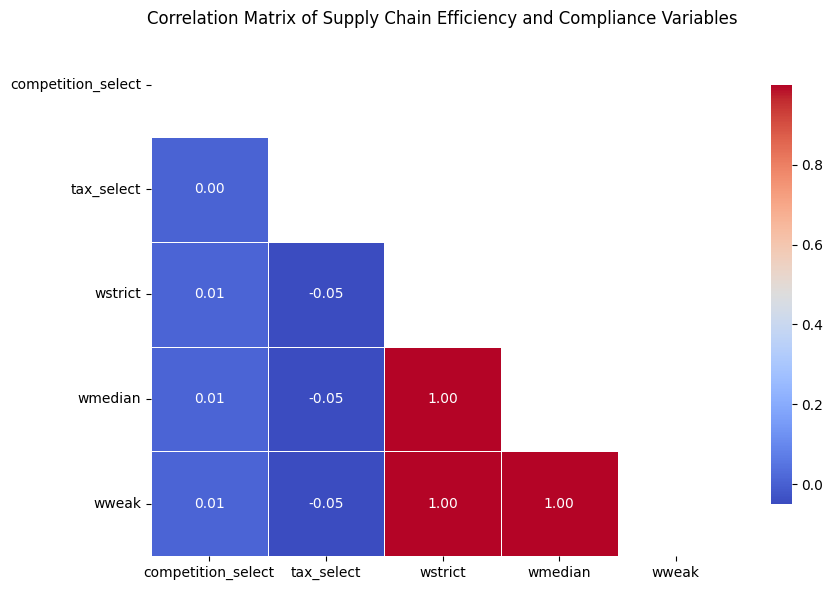

In [69]:
numeric_data = data.apply(pd.to_numeric, errors='coerce')

numeric_data = numeric_data.dropna(axis=1, how='all')
numeric_data = numeric_data.loc[:, numeric_data.nunique() > 1]

print(numeric_data.info())

corr_matrix = numeric_data.corr(method='pearson')
corr_matrix


import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(9,6))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix of Supply Chain Efficiency and Compliance Variables")
plt.tight_layout()
plt.show()


## Regression Analysis

In [72]:
import statsmodels.api as sm

X = data[['tax_select', 'vat_applicable', 'wstrict', 'wmedian']]
y = data['competition_select']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:     competition_select   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.004
Method:                 Least Squares   F-statistic:                    0.2615
Date:                Wed, 31 Dec 2025   Prob (F-statistic):              0.853
Time:                        11:02:17   Log-Likelihood:                -433.36
No. Observations:                 598   AIC:                             874.7
Df Residuals:                     594   BIC:                             892.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
tax_select         0.0049      0.041      0.

## Classification (Fraud / compliance perspective)

In [81]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

X = data[['wstrict', 'wmedian', 'wweak', 'a6a']]
y = data['vat_applicable']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))



              precision    recall  f1-score   support

          -1       1.00      1.00      1.00       180

    accuracy                           1.00       180
   macro avg       1.00      1.00      1.00       180
weighted avg       1.00      1.00      1.00       180



## Feature importance

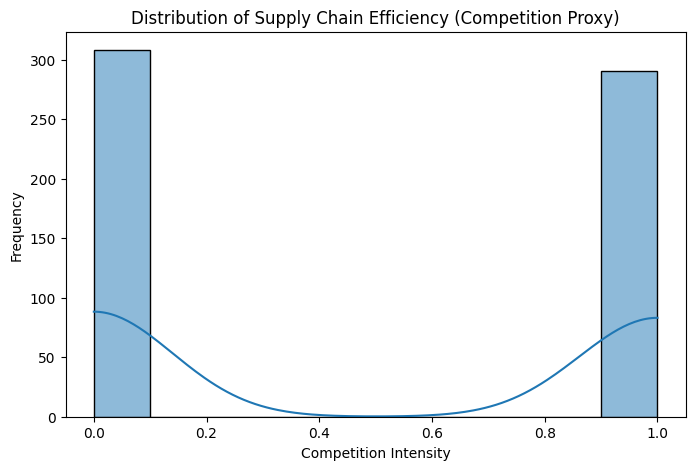

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(data['competition_select'], bins=10, kde=True)
plt.title("Distribution of Supply Chain Efficiency (Competition Proxy)")
plt.xlabel("Competition Intensity")
plt.ylabel("Frequency")
plt.show()





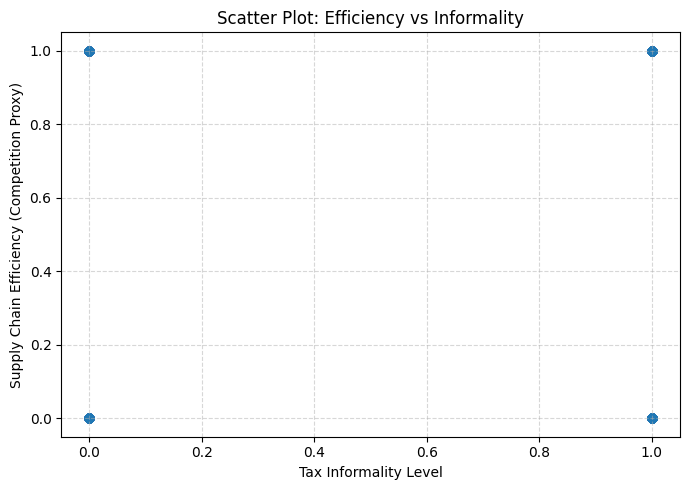

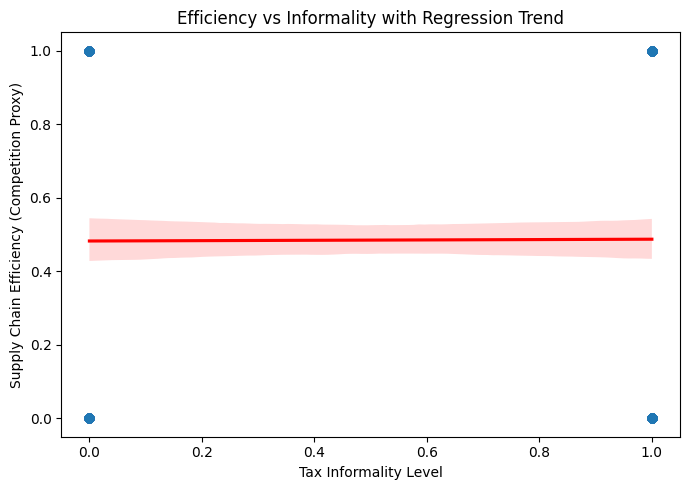

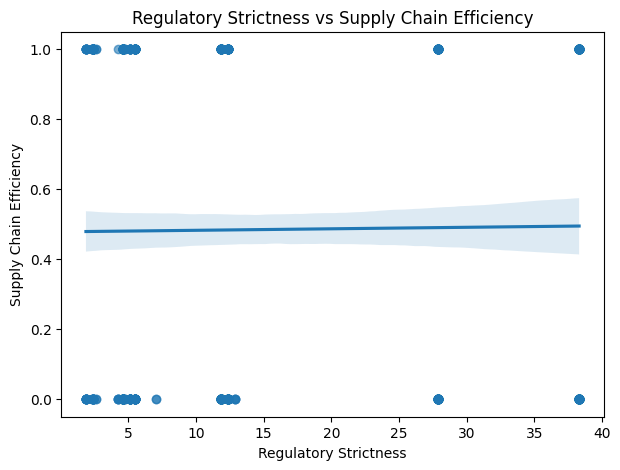

In [82]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(
    data['tax_select'],
    data['competition_select'],
    alpha=0.6
)

plt.xlabel("Tax Informality Level")
plt.ylabel("Supply Chain Efficiency (Competition Proxy)")
plt.title("Scatter Plot: Efficiency vs Informality")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


import seaborn as sns

plt.figure(figsize=(7,5))
sns.regplot(
    x='tax_select',
    y='competition_select',
    data=data,
    scatter_kws={'alpha':0.6},
    line_kws={'color':'red'}
)

plt.xlabel("Tax Informality Level")
plt.ylabel("Supply Chain Efficiency (Competition Proxy)")
plt.title("Efficiency vs Informality with Regression Trend")
plt.tight_layout()
plt.show()


plt.figure(figsize=(7,5))
sns.regplot(
    x='wstrict',
    y='competition_select',
    data=data,
    scatter_kws={'alpha':0.6}
)

plt.xlabel("Regulatory Strictness")
plt.ylabel("Supply Chain Efficiency")
plt.title("Regulatory Strictness vs Supply Chain Efficiency")
plt.show()


vat_applicable
-1    598
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


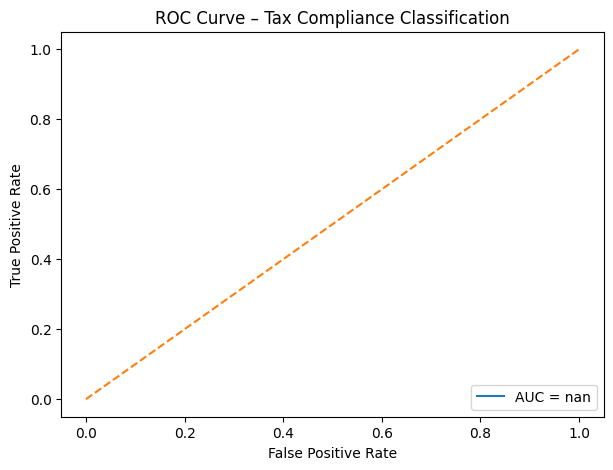

In [68]:
from sklearn.metrics import roc_curve, auc
print(data['vat_applicable'].value_counts())

if len(clf.classes_) == 2:
    y_prob = clf.predict_proba(X_test)[:, 1]
else:
    y_prob = clf.predict_proba(X_test)[:, 0]


fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label='AUC = %0.2f' % roc_auc)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Tax Compliance Classification')
plt.legend(loc='lower right')
plt.show()

